# Beyond the catalog: real out-of-taxonomy transients

### ZTF Summer School — bonus notebook

In `tutorial.ipynb` we *simulated* discovery by hiding the TDEs. But nature has
already given us classes missing from our training taxonomy entirely. Following
the out-of-taxonomy validation of ASTRANet (Sasli et al. 2026,
[arXiv:2607.08044](https://arxiv.org/abs/2607.08044)) — there for spectra, here
for photometry — we assembled real ZTF intruders from several rare families:

| class | what it is | our objects |
|---|---|---|
| **FBOT** | fast blue optical transient; rises in days, extremely blue | AT2018cow ("the Cow"), AT2021csp |
| **Ca-rich** | faint, fast SNe with calcium-dominated spectra | SN2019ehk, SN2021gno, SN2022oqm |
| **ILRT / gap** | intermediate-luminosity red transient — the SN/nova gap | AT2019abn |
| **SLSN-I** | superluminous supernova, months-long and 10-100x brighter | SN2020ank |
| **SN Iax** | weak, low-velocity cousin of Type Ia | SN2020kyg |

The photometry is fetched by `fetch_rare_transients.py` from the **BOOM**
alert broker (set `BOOM_URL` + credentials; the public ALeRCE API is used as an
automatic fallback so the notebook reproduces anywhere) and converted to the
training event format. Two families we tried could not pass the survey quality
cut: GRB afterglows and the jetted TDE AT2022cmc fade within hours-days, before
ZTF can accumulate eight detections — a cadence selection effect worth
remembering whenever you interpret "what a survey can discover".

Our training set contains SNe, CVs, AGN and TDEs — none of the classes above.
The question: *does the machinery from the tutorial flag them?*

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")
from flare import FlareClassifier, BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00",
               "FBOT": "#000000", "Ca-rich": "#56B4E9",
               "ILRT": "#999933", "SLSN-I": "#332288", "SN Iax": "#882255"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

meta = json.load(open("rare_transients/meta.json"))
ext_files = [f"rare_transients/{oid}.npz" for oid in meta]
ext_names = [m["name"] for m in meta.values()]
ext_class = [m["class"] for m in meta.values()]
print("external objects:", ", ".join(f"{n} ({c})" for n, c in zip(ext_names, ext_class)))

external objects: AT2018cow (FBOT), AT2021csp (FBOT), SN2019ehk (Ca-rich), SN2021gno (Ca-rich), SN2022oqm (Ca-rich), AT2019abn (ILRT), SN2020ank (SLSN-I), SN2020kyg (SN Iax)


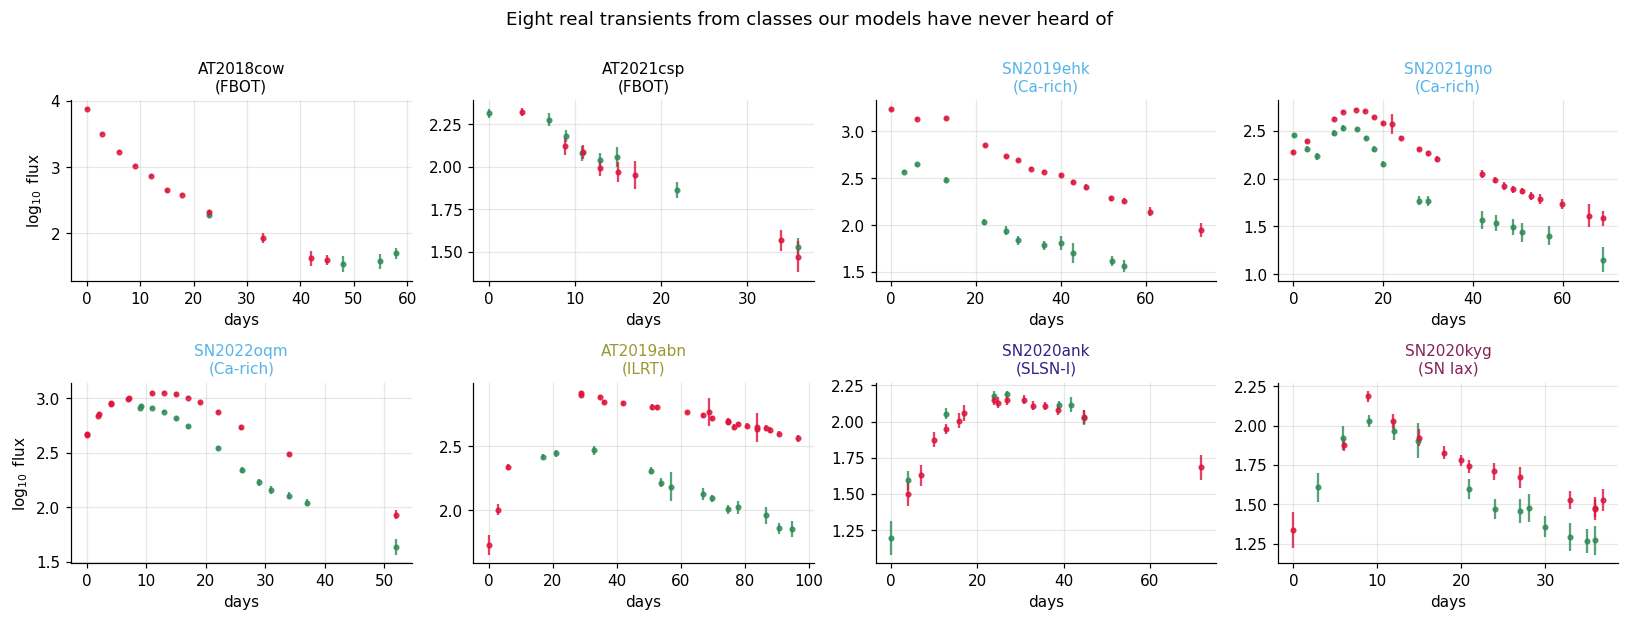

In [2]:
# Their real light curves
fig, axes = plt.subplots(2, 4, figsize=(15, 5.6))
for ax, f, n, c in zip(axes.ravel(), ext_files, ext_names, ext_class):
    bands = D.reconstruct_bands(D.load_events(f))
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.errorbar(bands[name].t, bands[name].logflux,
                        yerr=bands[name].logflux_err, fmt="o", ms=3,
                        color=colr, alpha=0.8)
    ax.set_title(f"{n}\n({c})", color=CLASS_COLOR[c], fontsize=10)
    ax.set_xlabel("days")
for ax in axes[:, 0]: ax.set_ylabel(r"$\log_{10}$ flux")
plt.suptitle("Eight real transients from classes our models have never heard of", y=1.0)
plt.tight_layout(); plt.show()

Note the FBOT signatures even by eye: rapid evolution, and the green (g) points
sitting high — extremely blue. The Ca-rich events look like small, fast
supernovae.

## What does the classifier call them?

The 5-class FLARE model *must* answer with one of its five classes — it has no
"none of the above" button.

In [3]:
clf5 = FlareClassifier.from_pretrained()
X_ext = clf5.features_from_files(ext_files)
P_ext = clf5.predict_proba(X_ext)
sets_ext = clf5.prediction_sets(X_ext)

tab = pd.DataFrame(P_ext, columns=BROAD_CLASSES, index=ext_names).round(2)
tab.insert(0, "true class", ext_class)
tab["prediction"] = [BROAD_CLASSES[i] for i in P_ext.argmax(1)]
tab["conformal set"] = ["|".join(s) for s in sets_ext]
tab

,true class,SNI,SNII,CV,AGN,TDE,prediction,conformal set
AT2018cow,FBOT,0.01,0.00,0.99,0.00,0.00,CV,CV
AT2021csp,FBOT,0.06,0.00,0.93,0.00,0.00,CV,CV
SN2019ehk,Ca-rich,0.93,0.07,0.00,0.00,0.00,SNI,SNI
SN2021gno,Ca-rich,0.68,0.32,0.00,0.00,0.00,SNI,SNII
SN2022oqm,Ca-rich,0.84,0.15,0.01,0.00,0.00,SNI,SNII
AT2019abn,ILRT,0.01,0.99,0.00,0.01,0.00,SNII,SNII
SN2020ank,SLSN-I,0.43,0.35,0.00,0.01,0.21,SNI,SNII|TDE
SN2020kyg,SN Iax,0.14,0.84,0.00,0.01,0.00,SNII,SNII


The classifier absorbs them into its nearest known classes — as it must. Some
conformal sets are already telling: an empty or multi-class set is the
conformal way of saying "nothing fits well". But to *rank* them as discoveries
we need the anomaly machinery.

## LUNA on the full five-class world

This time nothing is hidden: LUNA learns "normal" from the **complete** training
set (all five classes, TDEs included) with the full model's logits, then scores
the test set plus our eight intruders. With no labelled examples of any of
these classes anywhere, only the blind consensus is available — exactly the
situation a survey faces with a genuinely new class.

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from luna.pipeline import LUNAPipeline

# full 5-class training world
tr = pd.read_parquet("../../artifacts/features_train_h100.parquet")
ytr = tr["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
Xtr_raw = tr.drop(columns=["obj_id", "label"])

imputer = SimpleImputer(strategy="median").fit(Xtr_raw)
scaler  = RobustScaler().fit(imputer.transform(Xtr_raw))
embed = lambda Xdf: np.clip(scaler.transform(imputer.transform(Xdf)), -10, 10)
logits = lambda Xdf: clf5.booster.predict(Xdf, raw_score=True)

pipe = LUNAPipeline(target_far=0.01)
pipe.fit({"embeddings": embed(Xtr_raw), "labels": ytr, "logits": logits(Xtr_raw)})

# query pool: the whole test split as background + the eight intruders
manifest = D.load_manifest("test")
kept, _ = D.filter_manifest_quality(manifest)
y_test = np.array([ID2BROAD_ID[int(l)] for l in kept.label])
X_test = clf5.features_from_files(kept.filepath.tolist())      # ~1 min

X_pool = pd.concat([X_test.reset_index(drop=True), X_ext], ignore_index=True)
pool_names = np.concatenate([kept.obj_id.values, ext_names])
pool_class = np.concatenate([[BROAD_CLASSES[i] for i in y_test], ext_class])
is_new = ~np.isin(pool_class, BROAD_CLASSES)   # anything outside the taxonomy

scores = pipe.score({"embeddings": embed(X_pool), "logits": logits(X_pool)})
print(f"pool: {len(pool_names)} objects ({is_new.sum()} true intruders) | "
      f"{len(scores)} anomaly scores")

  [LUNA] fit msp in 0.0s


  [LUNA] fit entropy in 0.0s


  [LUNA] fit energy in 0.0s


  [LUNA] fit odin in 0.0s


  [LUNA] fit mahal_global in 0.0s


...

E20260726 15:38:55.838171 2142348 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260726 15:38:55.952505 2142348 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 15:38:56.083756 2142348 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260726 15:38:56.128163 2142348 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 15:38:56.344599 2142348 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260726 15:38:57.135138 2142348 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


pool: 1987 objects (8 true intruders) | 14 anomaly scores


In [5]:
from scipy.stats import rankdata

R = np.mean([rankdata(scores[k]) for k in scores], axis=0)
pct = 100.0 * rankdata(R) / len(R)          # anomaly percentile (100 = weirdest)

print("object      class     anomaly percentile   rank out of", len(R))
order = np.argsort(R)[::-1]
rank_of = {i: r + 1 for r, i in enumerate(order)}
for i in np.where(is_new)[0]:
    print(f"{pool_names[i]:11s} {pool_class[i]:8s}      {pct[i]:5.1f}%          "
          f"#{rank_of[i]}")

object      class     anomaly percentile   rank out of 1987
AT2018cow   FBOT           91.4%          #172
AT2021csp   FBOT           48.7%          #1020
SN2019ehk   Ca-rich        92.2%          #155
SN2021gno   Ca-rich        63.3%          #730
SN2022oqm   Ca-rich        90.1%          #198
AT2019abn   ILRT           88.9%          #221
SN2020ank   SLSN-I         48.3%          #1029
SN2020kyg   SN Iax         68.4%          #629


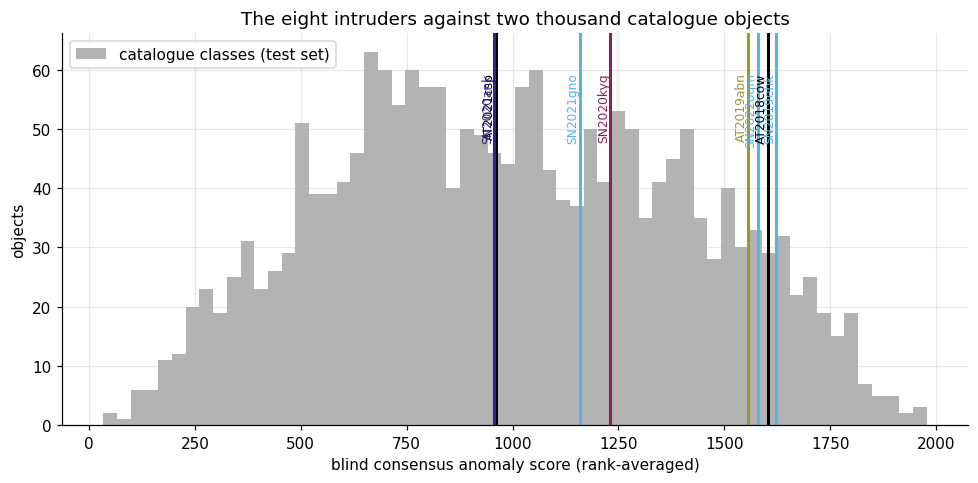

In [6]:
# Where the intruders sit in the anomaly distribution
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(R[~is_new], bins=60, color="0.7", label="catalogue classes (test set)")
for i in np.where(is_new)[0]:
    ax.axvline(R[i], color=CLASS_COLOR[pool_class[i]], lw=2)
    ax.annotate(pool_names[i], (R[i], ax.get_ylim()[1] * 0.9), rotation=90,
                fontsize=8, ha="right", va="top", color=CLASS_COLOR[pool_class[i]])
ax.set_xlabel("blind consensus anomaly score (rank-averaged)")
ax.set_ylabel("objects")
ax.set_title("The eight intruders against two thousand catalogue objects")
ax.legend()
plt.tight_layout(); plt.show()

## Which scorers react — and why

Different physics triggers different scorer families. For each intruder, the
scorers that rank it highest tell us *how* it is unusual.

In [7]:
rows = []
for i in np.where(is_new)[0]:
    pcts = {k: 100.0 * rankdata(s)[i] / len(s) for k, s in scores.items()}
    top3 = sorted(pcts, key=pcts.get, reverse=True)[:3]
    rows.append({"object": pool_names[i], "class": pool_class[i],
                 **{f"top{j+1}": f"{k} ({pcts[k]:.0f}%)" for j, k in enumerate(top3)}})
pd.DataFrame(rows)

,object,class,top1,top2,top3
0,AT2018cow,FBOT,pca_recon (99%),mahal_global (99%),knn (94%)
1,AT2021csp,FBOT,energy (90%),msp (87%),odin (87%)
2,SN2019ehk,Ca-rich,lof (98%),mahal_within (92%),mrs (92%)
3,SN2021gno,Ca-rich,msp (96%),odin (95%),entropy (94%)
4,SN2022oqm,Ca-rich,pca_recon (97%),mahal_within (94%),msp (92%)
5,AT2019abn,ILRT,lof (100%),pca_recon (95%),mrs (94%)
6,SN2020ank,SLSN-I,msp (99%),odin (99%),entropy (99%)
7,SN2020kyg,SN Iax,energy (93%),entropy (92%),msp (92%)


## A 3D map of the feature space

Where do the intruders actually *live*? We compress the 160-dimensional
embedding to three dimensions with UMAP, which preserves local neighbourhood
structure, and drop the intruders on top of the catalogue map.

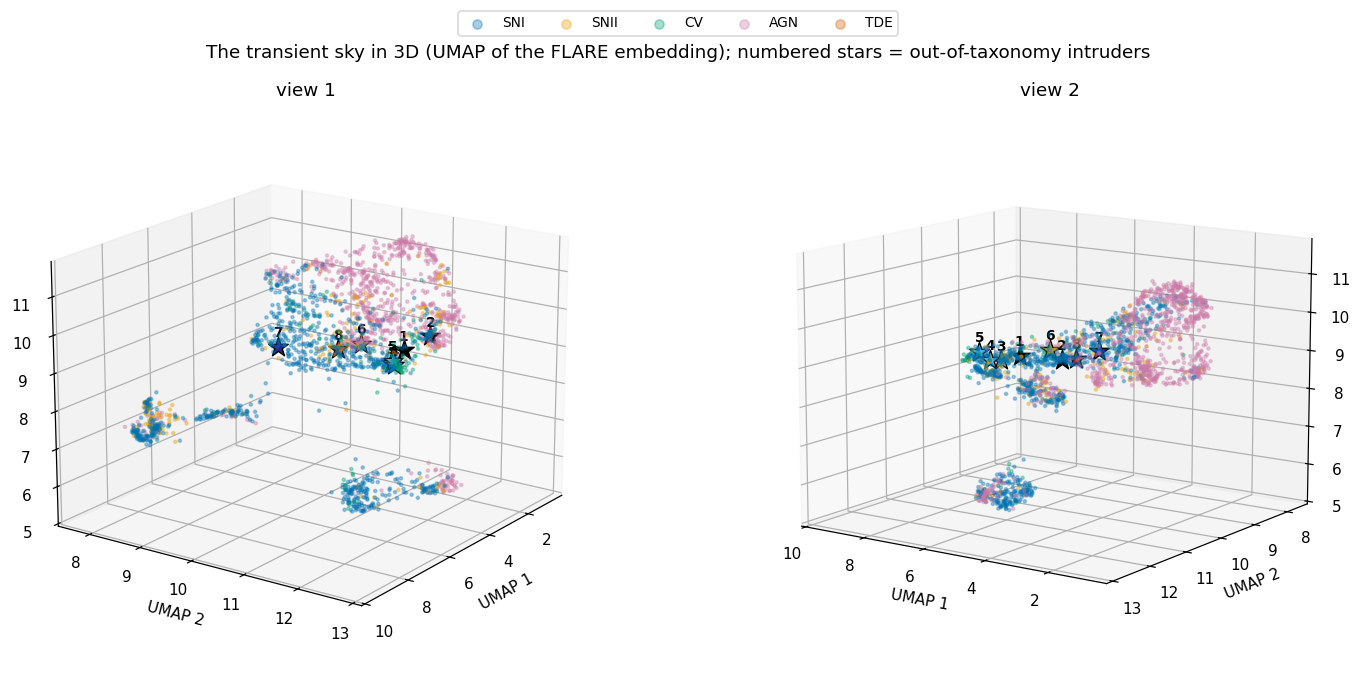

  1: AT2018cow (FBOT)
  2: AT2021csp (FBOT)
  3: SN2019ehk (Ca-rich)
  4: SN2021gno (Ca-rich)
  5: SN2022oqm (Ca-rich)
  6: AT2019abn (ILRT)
  7: SN2020ank (SLSN-I)
  8: SN2020kyg (SN Iax)


In [8]:
import umap

reducer = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1,
                    random_state=42)
E = embed(X_pool)
Z = reducer.fit_transform(E)

fig = plt.figure(figsize=(14, 6))
for k, (elev, azim) in enumerate([(18, 35), (12, 125)]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    for cls in BROAD_CLASSES:
        m = pool_class == cls
        ax.scatter(Z[m, 0], Z[m, 1], Z[m, 2], s=4, alpha=0.35,
                   color=CLASS_COLOR[cls], label=cls if k == 0 else None)
    for j, i in enumerate(np.where(is_new)[0], 1):
        ax.scatter(*Z[i], s=180, marker="*", color=CLASS_COLOR[pool_class[i]],
                   edgecolor="black", linewidth=0.9, zorder=6)
        ax.text(Z[i, 0], Z[i, 1], Z[i, 2] + 0.25, str(j), fontsize=9,
                fontweight="bold", ha="center", zorder=7)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.set_zlabel("UMAP 3")
    ax.set_title(f"view {k+1}")
fig.legend(loc="upper center", ncol=5, fontsize=9, markerscale=3,
           bbox_to_anchor=(0.5, 1.04))
plt.suptitle("The transient sky in 3D (UMAP of the FLARE embedding); "
             "numbered stars = out-of-taxonomy intruders", y=0.98)
plt.tight_layout(); plt.show()

for j, i in enumerate(np.where(is_new)[0], 1):
    print(f"  {j}: {pool_names[i]} ({pool_class[i]})")

Read the map against the anomaly scores from before: the intruders that ranked
at the 89th-92nd percentile sit at cluster edges or in sparse regions, while the
ones that hid (AT2021csp, SN2020ank) fall comfortably *inside* a known island —
the geometric reason a distance- or density-based scorer cannot see them.

## "What is the Cow like?"

The same embedding powers retrieval (see `../similarity_search.ipynb` for the
full lesson). When an anomaly candidate lands on your desk, the first question
is: *what known objects resemble it most?* The answer contextualises the
anomaly — and if the neighbours are a mixed bag, that itself is evidence of
novelty.

query: AT2018cow (FBOT) — 5 nearest catalogue neighbours:

rank  object          class  cosine distance
  1   ZTF19acrbzdn    CV     0.258
  2   ZTF19acmyljb    SNI    0.275
  3   ZTF19acbihyi    SNI    0.303
  4   ZTF21aceepnp    SNI    0.306
  5   ZTF19aavnxej    CV     0.307


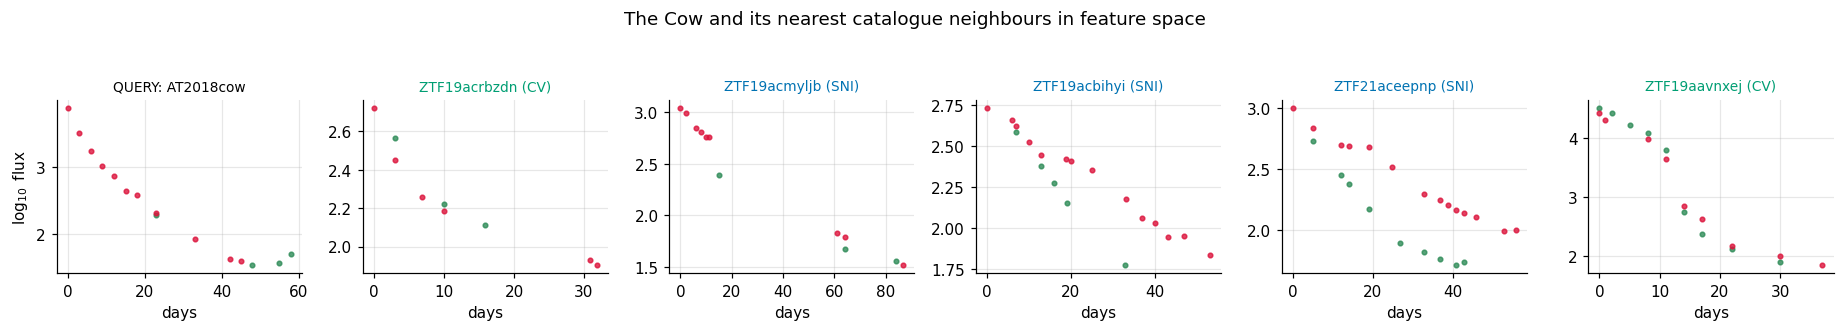

In [9]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=6, metric="cosine").fit(E[:len(X_test)])

q = list(pool_names).index("AT2018cow")
dist, ind = nn.kneighbors(E[q:q+1])

print("query: AT2018cow (FBOT) — 5 nearest catalogue neighbours:\n")
print("rank  object          class  cosine distance")
for r, (i, d) in enumerate(zip(ind[0][:5], dist[0][:5]), 1):
    print(f"  {r}   {pool_names[i]:15s} {pool_class[i]:5s}  {d:.3f}")

fig, axes = plt.subplots(1, 6, figsize=(17, 2.8))
files = [dict(zip(pool_names, np.concatenate([kept.filepath.values, ext_files])))[n]
         for n in [pool_names[q]] + [pool_names[i] for i in ind[0][:5]]]
titles = ["QUERY: AT2018cow"] + [f"{pool_names[i]} ({pool_class[i]})" for i in ind[0][:5]]
colors = ["#000000"] + [CLASS_COLOR[pool_class[i]] for i in ind[0][:5]]
for ax, f, t, c in zip(axes, files, titles, colors):
    bands = D.reconstruct_bands(D.load_events(f))
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.plot(bands[name].t, bands[name].logflux, "o", ms=3,
                    color=colr, alpha=0.8)
    ax.set_title(t, color=c, fontsize=9)
    ax.set_xlabel("days")
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.suptitle("The Cow and its nearest catalogue neighbours in feature space", y=1.06)
plt.tight_layout(); plt.show()

The neighbours are the fastest, bluest things the catalogue can offer — yet
none of them is a great match, and their class labels disagree. A mixed,
distant neighbourhood is exactly the retrieval signature of something new.

## Takeaways

1. Classes absent from the taxonomy are silently absorbed into the nearest
   known class — with no error message. Only anomaly analysis reveals them.
2. Blind consensus does real work with zero labels: half of the intruders
   (AT2018cow, SN2019ehk, SN2022oqm, AT2019abn) land at the 89th-92nd
   percentile — inside the shortlist a survey scientist would actually
   inspect. Fast, faint, or very blue objects stand out.
3. But it is not magic: AT2021csp and the superluminous SN2020ank sit
   mid-pack (~48th percentile) and SN2021gno/SN2020kyg around the 60s. A
   months-long SLSN photometrically resembles a slow SNII or TDE closely
   enough to hide — discovery is a funnel, not a filter, and what hides tells
   you as much as what stands out.
4. The scorer breakdown is diagnostic: different families (uncertainty,
   distance, density) fire for different intruders, hinting at *what kind* of
   new thing each is.
5. The full loop from the tutorial applies unchanged: once one FBOT is
   confirmed, a supervised combiner turns the blind search into a targeted one.

### Exercises

1. **Sample size.** The external light curves have 15-41 detections — sparser
   than typical training objects. How would you test whether the anomaly score
   reacts to the *physics* or the *cadence*? (Hint: subsample catalogue light
   curves to the same number of detections and re-score them.)
2. **Why do AT2021csp and SN2020ank hide?** Inspect their top scorers and
   classifier probabilities. Which known class is each mimicking, in which
   features — and would a longer horizon (SLSNe evolve for ~200 days) help?
3. **More intruders.** Query BOOM (or ALeRCE) for additional out-of-catalog
   objects — novae, changing-look AGN, more gap transients — add them to
   `fetch_rare_transients.py`, and score them.
4. **The Cow's colour.** Extract `g_r_mean` for AT2018cow and compare it to the
   distribution over each training class. Is it bluer than the TDEs?

---
*Data: ZTF alert photometry via the BOOM broker (ALeRCE public fallback).
Packages: [FLARE](https://github.com/appleapplecider-ml/flare),
[LUNA](https://github.com/asasli/luna). Companion paper for the
out-of-taxonomy methodology: [arXiv:2607.08044](https://arxiv.org/abs/2607.08044).*